In [ ]:
import marimo as mo
import polars as pl
from spacy.lang.es.stop_words import STOP_WORDS

from utils import barh, chat_dirs, columns, connect, heatmap, note
from wasap_group_analyzer.config import load_params
from wasap_group_analyzer.text import (
    CHAT_STOP_WORDS,
    clean_content,
    emoji_name,
    extract_emojis,
    is_edited,
    load_nlp,
    message_type,
    text_for_words,
    tokenize,
)

# Tamaño de la muestra de mensajes de texto para explorar con spaCy (la muestra es
# reproducible: misma semilla, mismos mensajes).
SAMPLE_SIZE = 20_000

# EDA silver: de los mensajes anonimizados a datos tidy

El job de anonimización dejó `data/interim/<chat>/messages_anon.parquet`: una fila por
registro con `message_id`, `timestamp`, `sender_id`, `kind` y el `body` enmascarado.
Este notebook decide, con datos, cómo convertirlo en los conjuntos tidy de silver
(`data/processed/<chat>/`): qué tipos de mensaje hay, qué es contenido, cómo se
nombran los miembros, qué cuenta como palabra y como emoji, qué palabras son vacías
y cómo encontrar adjetivos.

Lo que decide aquí está implementado en el paquete (`wasap_group_analyzer/text.py` y
`aliases.py`) y lo usa el job de silver; el notebook lo aplica a los datos para
justificarlo.

**Privacidad.** Solo se lee la versión anonimizada, y nunca se muestra un mensaje
completo: solo conteos, palabras sueltas y ejemplos inventados.

In [ ]:
dirs = chat_dirs()
con = connect()

# Funciones del paquete disponibles en SQL.
con.create_function(
    "message_type", message_type, ["VARCHAR", "VARCHAR"], "VARCHAR", null_handling="special"
)
con.create_function("is_edited", is_edited, ["VARCHAR"], "BOOLEAN", null_handling="special")
con.create_function("emojis", extract_emojis, ["VARCHAR"], "VARCHAR[]", null_handling="special")
con.create_function("emoji_name", emoji_name, ["VARCHAR"], "VARCHAR")

# Alias de cada miembro: los asigna el job de anonimización (ver sección 3).
member_aliases = con.sql("SELECT sender_id, alias FROM members").pl()
alias_by_id = dict(zip(member_aliases["sender_id"], member_aliases["alias"]))
con.create_function(
    "clean_content",
    lambda kind, body: clean_content(kind, body, alias_by_id),
    ["VARCHAR", "VARCHAR"],
    "VARCHAR",
    null_handling="special",
)
note(f"Chat activo: **{dirs['chat']}**")

Chat activo: baketon_city

## 1. La entrada

`avisos_del_grupo` son los mensajes que WhatsApp firma con el nombre del grupo y no
con una persona (el aviso de cifrado, la llegada de Meta AI): su `sender_id` queda
vacío y no reciben alias. `con_cuerpo` son los registros que conservan texto, es
decir, los de tipo `text`, `attachment` y `poll`.

In [ ]:
overview = mo.sql(
    f"""
    SELECT
        count(*) AS registros,
        count(DISTINCT sender_id) AS personas,
        count(*) FILTER (sender_id IS NULL) AS avisos_del_grupo,
        count(*) FILTER (body IS NOT NULL) AS con_cuerpo,
        min(timestamp) AS desde,
        max(timestamp) AS hasta
    FROM messages_anon
    """,
    engine=con
)

registros,personas,avisos_del_grupo,con_cuerpo,desde,hasta
259014,42,11,256528,2024-09-28 14:31:21,2026-09-18 16:45:29


## 2. Tipos de mensaje

`kind` junta todos los adjuntos en `attachment`, pero para responder "¿quién manda
más stickers?" hay que separarlos. El marcador que deja WhatsApp (`sticker omitted`,
`image omitted`...) da el tipo: `text.message_type()` convierte `kind` en
`message_type`, igual a `kind` salvo en los adjuntos.

In [ ]:
types = mo.sql(
    f"""
    SELECT
        message_type(kind, body) AS message_type,
        count(*) AS mensajes,
        round(100 * count(*) / sum(count(*)) OVER (), 2) AS pct,
        count(*) FILTER (kind = 'attachment' AND clean_content(kind, body) IS NOT NULL)
            AS con_pie_de_foto
    FROM messages_anon
    GROUP BY ALL
    ORDER BY mensajes DESC
    """,
    engine=con
)

message_type,mensajes,pct,con_pie_de_foto
"""text""",226829,87.57,0
"""sticker""",21159,8.17,0
"""image""",7220,2.79,3232
"""view_once""",1393,0.54,0
"""deleted""",414,0.16,0
"""audio""",409,0.16,0
"""video""",338,0.13,103
"""gif""",287,0.11,25
"""unavailable""",280,0.11,0
"""poll""",177,0.07,0


Los tipos se quedan como están, con una aclaración para las preguntas: los *mensajes
de texto* (para palabras por mensaje) son solo `text`. Los pies de foto y las
encuestas también son texto escrito por alguien, así que sus palabras sí cuentan para
"las palabras más usadas", pero no como mensajes de texto.

## 3. Alias de los miembros

Cada `sender_id` recibe el nombre de un animal de México: "Ajolote", "Jaguar",
"Quetzal", "Tlacuache". Se asignan en el orden en que cada miembro escribió por
primera vez, así que quien habló primero es Ajolote. (La exportación empieza a media
conversación, así que muchos primeros mensajes caen el primer día; entre ellos manda
la hora.) El orden no depende del hash, y una exportación más nueva solo agrega
animales al final.

Los asigna el job de anonimización (`interim/<chat>/members.parquet`) porque es el
único que conoce los nombres reales: salta cualquier animal que comparta una palabra
con el nombre de un miembro, para que el alias no dé ninguna pista sobre quién es.
Son nombres de una sola palabra, fáciles de distinguir en una gráfica.

In [ ]:
aliases_table = mo.sql(
    f"""
    SELECT m.alias, m.first_message AS primer_mensaje, count(*) AS mensajes
    FROM members AS m
    JOIN messages_anon USING (sender_id)
    GROUP BY ALL
    ORDER BY primer_mensaje
    """,
    engine=con
)

alias,primer_mensaje,mensajes
"""Ajolote""",2024-09-28 14:31:21,5313
"""Jaguar""",2024-09-28 14:34:04,10790
"""Coyote""",2024-09-28 14:36:38,9430
"""Quetzal""",2024-09-28 14:55:02,17787
"""Tlacuache""",2024-09-28 14:56:05,34554
"""Armadillo""",2024-09-28 14:58:44,1933
"""Colibrí""",2024-09-28 15:06:11,13758
"""Tucán""",2024-09-28 15:06:23,14783
"""Ocelote""",2024-09-28 15:13:10,1049
"""Puma""",2024-09-28 16:29:03,15450


## 4. Contenido legible

El `body` de interim todavía trae ruido: marcas invisibles, el sufijo
`<This message was edited>`, el marcador del adjunto y los ids de las marcas de
anonimización. `text.clean_content()` deja el texto que escribió el usuario, con los
miembros como `@[Alias]` (mención) o `[Alias]` (nombre en el texto). Los corchetes
distinguen a un miembro anonimizado de, por ejemplo, alguien hablando de Juárez.
Para contar palabras, `text.text_for_words()` quita además todas las marcas entre
corchetes y las etiquetas de las encuestas.

Con mensajes inventados:

In [ ]:
_lrm = chr(0x200E)
_someone = next(iter(alias_by_id))
_examples = [
    ("text", f"nos vemos mañana @[{_someone}] 😂 {_lrm}<This message was edited>"),
    ("attachment", f"mira esto [{_someone}] {_lrm}image omitted"),
    ("attachment", f"{_lrm}sticker omitted"),
    ("text", "checa [url:youtube.com] y me dices, [nombre] ya lo vio"),
    ("poll", "POLL:\n¿Dónde comemos?\nOPTION: Tacos (3 votes)\nOPTION: Pizza (1 vote)"),
]
_rows = []
for _kind, _body in _examples:
    _content = clean_content(_kind, _body, alias_by_id)
    _rows.append(
        {
            "kind": _kind,
            "body en interim": _body.replace(_lrm, "‹U+200E›"),
            "is_edited": is_edited(_body),
            "content": _content,
            "texto para palabras": " ".join(text_for_words(_content).split()),
        }
    )
pl.DataFrame(_rows)

kind,body en interim,is_edited,content,texto para palabras
"""text""","""nos vemos mañana @[5a34656d26] 😂 ‹U+200E›<This message was edited>""",true,"""nos vemos mañana @[Ajolote] 😂""","""nos vemos mañana 😂"""
"""attachment""","""mira esto [5a34656d26] ‹U+200E›image omitted""",false,"""mira esto [Ajolote]""","""mira esto"""
"""attachment""","""‹U+200E›sticker omitted""",false,null,""""""
"""text""","""checa [url:youtube.com] y me dices, [nombre] ya lo vio""",false,"""checa [url:youtube.com] y me dices, [nombre] ya lo vio""","""checa y me dices, ya lo vio"""
"""poll""","""POLL: ¿Dónde comemos? OPTION: Tacos (3 votes) OPTION: Pizza (1 vote)""",false,"""POLL: ¿Dónde comemos? OPTION: Tacos (3 votes) OPTION: Pizza (1 vote)""","""¿Dónde comemos? Tacos Pizza"""


In [ ]:
content_marks = mo.sql(
    f"""
    WITH c AS (
        SELECT kind, body, clean_content(kind, body) AS content
        FROM messages_anon
        WHERE body IS NOT NULL
    )
    SELECT
        count(*) FILTER (content IS NOT NULL) AS con_contenido,
        count(*) FILTER (is_edited(body)) AS editados,
        count(*) FILTER (contains(content, '@[')) AS con_mencion,
        count(*) FILTER (
            len(list_filter(
                regexp_extract_all(content, '(^|[^@])[[]([^]]+)[]]', 2),
                x -> x NOT IN ('nombre', 'numero', 'correo') AND NOT starts_with(x, 'url:')
            )) > 0
        ) AS con_nombre_de_miembro,
        count(*) FILTER (contains(content, '[nombre]')) AS con_nombre_ambiguo_o_apodo,
        count(*) FILTER (contains(content, '[url:')) AS con_url,
        count(*) FILTER (contains(content, '[numero]')) AS con_numero,
        count(*) FILTER (contains(content, '[correo]')) AS con_correo
    FROM c
    """,
    engine=con
)

con_contenido,editados,con_mencion,con_nombre_de_miembro,con_nombre_ambiguo_o_apodo,con_url,con_numero,con_correo
230411,1938,7746,12393,5069,739,433,36


## 5. Emojis

`text.extract_emojis()` usa la librería `emoji`, que reconoce secuencias completas: un
emoji con tono de piel (👍🏽) o una familia unida con ZWJ cuenta como uno solo. Los
emoticonos de texto como `:(` o `xD` no son emojis.

In [ ]:
emoji_summary = mo.sql(
    f"""
    WITH e AS (
        SELECT message_id, unnest(emojis(clean_content(kind, body))) AS emoji
        FROM messages_anon
        WHERE body IS NOT NULL
    )
    SELECT
        count(DISTINCT message_id) AS mensajes_con_emoji,
        count(*) AS emojis,
        count(DISTINCT emoji) AS emojis_distintos,
        count(*) FILTER (contains(emoji, chr(8205))) AS secuencias_zwj,
        count(*) FILTER (
            regexp_matches(emoji, '[' || chr(127995) || '-' || chr(127999) || ']')
        ) AS con_tono_de_piel
    FROM e
    """,
    engine=con
)

mensajes_con_emoji,emojis,emojis_distintos,secuencias_zwj,con_tono_de_piel
5664,10132,739,248,195


In [ ]:
top_emojis = mo.sql(
    f"""
    SELECT emoji, emoji_name(emoji) AS nombre, count(*) AS veces
    FROM (
        SELECT unnest(emojis(clean_content(kind, body))) AS emoji
        FROM messages_anon
        WHERE body IS NOT NULL
    )
    GROUP BY emoji
    ORDER BY veces DESC
    LIMIT 15
    """,
    engine=con
)

emoji,nombre,veces
"""😭""","""cara llorando fuerte""",512
"""🔥""","""fuego""",470
"""😍""","""cara sonriendo con ojos de corazón""",413
"""🗣️""","""cabeza parlante""",400
"""🥶""","""cara con frío""",389
"""✅""","""botón de marca de verificación""",294
"""🥵""","""cara con calor""",287
"""😂""","""cara llorando de risa""",284
"""👀""","""ojos""",245
"""🥰""","""cara sonriendo con corazones""",205


Los emojis son poco frecuentes comparados con los stickers: este grupo se expresa más
con stickers que con emojis. Cada emoji encontrado será una fila de la tabla
`emojis` de silver, con su nombre en español.

## 6. Qué cuenta como palabra

Para palabras, adjetivos y stop words se usa spaCy (`es_core_news_sm`), que separa
tokens, etiqueta su categoría gramatical (POS) y da su lema. Para explorar basta una
muestra reproducible de mensajes de texto; el job de silver procesa todos.

In [ ]:
sample = con.sql(
    f"""
    SELECT message_id, clean_content(kind, body) AS content
    FROM (SELECT * FROM messages_anon WHERE kind = 'text')
    USING SAMPLE reservoir({SAMPLE_SIZE} ROWS) REPEATABLE (42)
    """
).pl()
_words_text = [text_for_words(content) for content in sample["content"]]
sample = sample.with_columns(
    pl.Series("split_by_spaces", [len(text.split()) for text in _words_text])
)
nlp = load_nlp(load_params()["nlp"]["model"])
_rows = []
for _message_id, _tokens in zip(sample["message_id"], tokenize(nlp, _words_text)):
    _rows += [{"message_id": _message_id, **_token} for _token in _tokens]
sample_tokens = pl.DataFrame(_rows).with_columns(
    pl.col("token").is_in(list(STOP_WORDS)).alias("is_spacy_stop")
)
con.register("sample", sample)
con.register("sample_tokens", sample_tokens)
note(f"Muestra: **{len(sample):,}** mensajes de texto, **{len(sample_tokens):,}** tokens.")

Muestra: 20,000 mensajes de texto, 105,017 tokens.

Un mensaje inventado, token por token. Una **palabra** es un token alfabético
(`is_alpha`: solo letras, con o sin acento); números, signos, emojis y emoticonos son
tokens pero no palabras:

In [ ]:
_example = "jajaja no manches 😂 mañana a las 5pm vamos al cine, está buenísima la peli xD"
pl.DataFrame(next(tokenize(nlp, [_example]))).drop("token_idx")

token,lemma,pos,is_alpha,is_stop,is_laugh
"""jajaja""","""jajaja""","""NOUN""",true,true,true
"""no""","""no""","""ADV""",true,true,false
"""manches""","""manch""","""NOUN""",true,false,false
"""😂""","""😂""","""ADP""",false,false,false
"""mañana""","""mañana""","""ADV""",true,false,false
"""a""","""a""","""ADP""",true,true,false
"""las""","""el""","""DET""",true,true,false
"""5""","""5""","""NUM""",false,false,false
"""pm""","""pm""","""ADP""",true,false,false
"""vamos""","""ir""","""VERB""",true,true,false


In [ ]:
definitions = mo.sql(
    f"""
    WITH per_message AS (
        SELECT
            s.message_id,
            s.split_by_spaces AS por_espacios,
            count(t.token) FILTER (t.is_alpha) AS palabras
        FROM sample AS s
        LEFT JOIN sample_tokens AS t USING (message_id)
        GROUP BY ALL
    )
    SELECT
        round(avg(por_espacios), 2) AS promedio_separando_por_espacios,
        round(avg(palabras), 2) AS promedio_palabras_spacy,
        median(palabras) AS mediana_palabras_spacy,
        count(*) FILTER (palabras = 0) AS mensajes_sin_palabras
    FROM per_message
    """,
    engine=con
)

promedio_separando_por_espacios,promedio_palabras_spacy,mediana_palabras_spacy,mensajes_sin_palabras
4.99,4.85,4.0,704


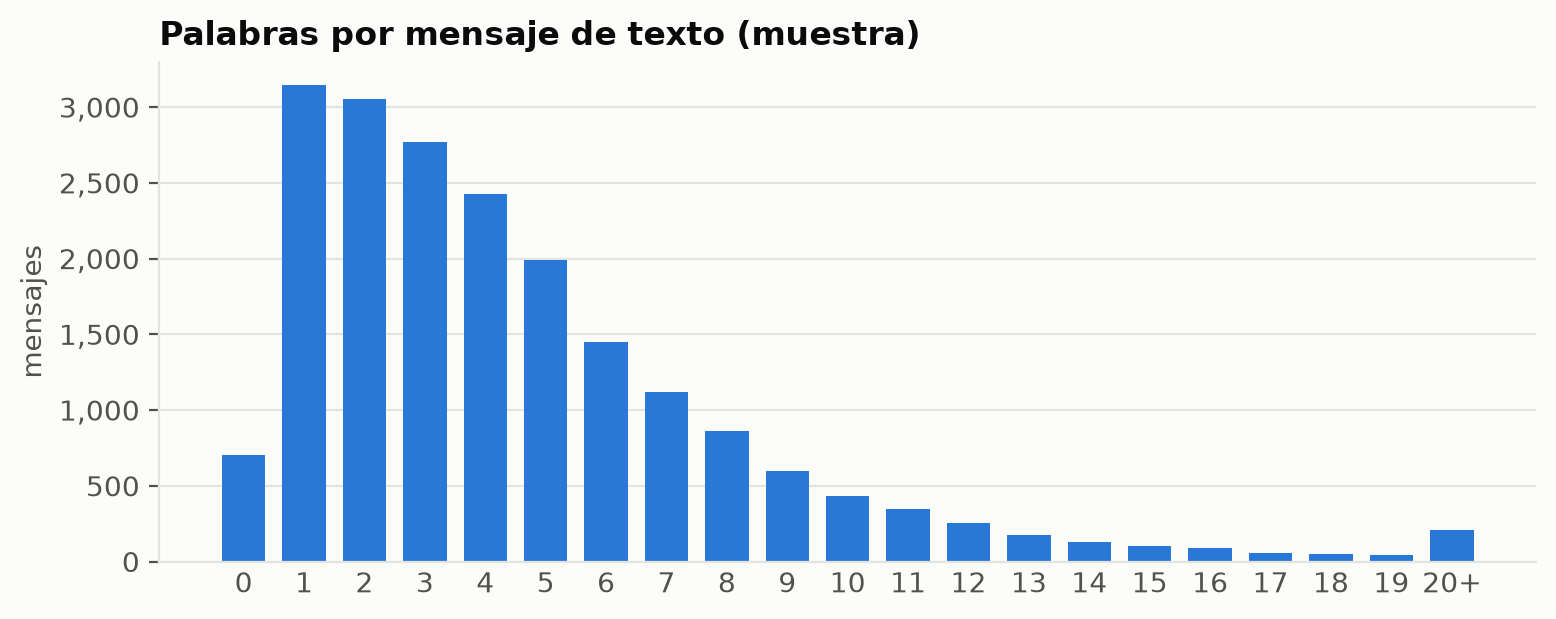

In [ ]:
words_per_message = mo.sql(
    f"""
    SELECT least(palabras, 20) AS palabras, count(*) AS mensajes
    FROM (
        SELECT s.message_id, count(t.token) FILTER (t.is_alpha) AS palabras
        FROM sample AS s LEFT JOIN sample_tokens AS t USING (message_id)
        GROUP BY s.message_id
    )
    GROUP BY 1
    ORDER BY 1
    """,
    engine=con,
    output=False,
)
columns(
    [str(n) if n < 20 else "20+" for n in words_per_message["palabras"]],
    words_per_message["mensajes"],
    "Palabras por mensaje de texto (muestra)",
    "mensajes",
)

Separar por espacios cuenta de más: "5pm", "😂" y "xD" no son palabras. Los mensajes
son cortos (la mitad tiene 4 palabras o menos), típico de un chat donde se escribe en
ráfagas. Los mensajes sin palabras son solo emojis, números o signos.

## 7. Risas

Las risas son las "palabras" más escritas del chat después de las vacías, con muchas
variantes. `text.LAUGH` reconoce al menos dos sílabas iguales (`jaja`, `jejeje`,
`haha`), variantes con s (`jsjsjs`), `xd` y `lol`, sin atrapar palabras reales como
"he", "ha" o "hijo". Cada token lleva `is_laugh` en silver y cuenta como palabra
vacía:

In [ ]:
laughs = mo.sql(
    f"""
    SELECT token AS risa, count(*) AS veces
    FROM sample_tokens
    WHERE is_laugh
    GROUP BY token
    ORDER BY veces DESC
    LIMIT 15
    """,
    engine=con
)

risa,veces
"""jaja""",87
"""jajaja""",80
"""xd""",72
"""jajajaja""",45
"""lol""",38
"""jajaj""",36
"""jajajajaja""",25
"""jajajaj""",22
"""jajajajajaja""",14
"""jeje""",13


## 8. Palabras vacías (stop words)

Con solo la lista de spaCy (`STOP_WORDS`, ~500 palabras del español escrito), las
palabras "con contenido" más frecuentes son en realidad muletillas y abreviaturas del
chat:

In [ ]:
spacy_only = mo.sql(
    f"""
    SELECT token AS palabra, count(*) AS veces
    FROM sample_tokens
    WHERE is_alpha AND NOT is_spacy_stop
    GROUP BY token
    ORDER BY veces DESC
    LIMIT 25
    """,
    engine=con
)

palabra,veces
"""we""",916
"""q""",909
"""pa""",304
"""verga""",195
"""pq""",189
"""casa""",156
"""pedo""",153
"""w""",152
"""vas""",151
"""d""",149


In [ ]:
note(
    "Por eso `text.CHAT_STOP_WORDS` agrega abreviaturas de palabras vacías, muletillas "
    "y vocativos del chat, y `text.is_stop_word()` considera vacía también cualquier "
    "palabra de una sola letra y cualquier risa. La jerga con significado (*neta*, "
    "*chamba*, *pedo*) sigue siendo contenido. La lista:\n\n"
    + ", ".join(f"`{word}`" for word in sorted(CHAT_STOP_WORDS))
)

Por eso text.CHAT_STOP_WORDS agrega abreviaturas de palabras vacías, muletillas y vocativos del chat, y text.is_stop_word() considera vacía también cualquier palabra de una sola letra y cualquier risa. La jerga con significado ( neta , chamba , pedo ) sigue siendo contenido. La lista: 
 ah , aja , ajá , ay , bro , eh , guey , güey , k , ke , mm , mmm , mmmm , nel , nomas , nomás , nop , ntp , oh , ok , okay , oki , osea , pa , pal , pk , porq , pos , pq , ps , q , qe , simon , sip , smn , tambn , tb , tmb , tmbn , uh , va , we , wey , xq

In [ ]:
content_words = mo.sql(
    f"""
    SELECT token AS palabra, count(*) AS veces
    FROM sample_tokens
    WHERE is_alpha AND NOT is_stop
    GROUP BY token
    ORDER BY veces DESC
    LIMIT 25
    """,
    engine=con
)

palabra,veces
"""verga""",195
"""casa""",156
"""pedo""",153
"""vas""",151
"""chino""",146
"""amigo""",125
"""fc""",109
"""qp""",102
"""gracias""",97
"""tienes""",95


## 9. Adjetivos

spaCy etiqueta cada token con su categoría gramatical (`pos`); los adjetivos son
`ADJ`. Se cuentan por lema, para que *buenas* y *bueno* sean el mismo adjetivo; las
formas cortas (*buen*, *gran*, *mal*) se unifican con la larga.

Aquí **no** se filtran las palabras vacías: la lista de spaCy incluye justo los
adjetivos más comunes (*bueno*, *mejor*, *nuevo*, *primero*, *grande*), y quitarlos
dejaría fuera la respuesta. Solo se excluyen las risas y las letras sueltas.

In [ ]:
adjectives = mo.sql(
    f"""
    SELECT lemma AS adjetivo, count(*) AS veces
    FROM sample_tokens
    WHERE pos = 'ADJ' AND is_alpha AND NOT is_laugh AND length(token) > 1
    GROUP BY lemma
    ORDER BY veces DESC
    LIMIT 30
    """,
    engine=con
)

adjetivo,veces
"""bueno""",219
"""mejor""",114
"""vergo""",65
"""primero""",63
"""nuevo""",62
"""solo""",60
"""chino""",55
"""puro""",48
"""amigo""",41
"""feliz""",40


La mayoría son adjetivos reales (*bueno*, *mejor*, *primero*, *nuevo*, *puro*,
*grande*, *viejo*), pero el modelo pequeño de spaCy se entrenó con noticias, no con
chats, y comete errores con la jerga y los mensajes sin puntuación: toma como
adjetivo algún sustantivo (*amigo*), verbo (*anda*) o abreviatura, y a veces no
lematiza el femenino (*buena* aparece aparte de *bueno*). Se acepta esa limitación y
se comenta al responder la pregunta, en lugar de corregir la lista a mano.

## 10. Especificación de silver

El job de silver (`make process`) escribe tres conjuntos tidy en
`data/processed/<chat>/`, cada uno con su diccionario de datos en `references/`:

**`messages.parquet`**: una fila por mensaje.

| Columna | Qué es |
|---|---|
| `message_id` | orden del registro en el archivo exportado |
| `timestamp` | fecha y hora local, sin zona |
| `sender` | alias del remitente (un animal); vacío en avisos del grupo |
| `message_type` | tipo de mensaje (sección 2) |
| `content` | texto legible (sección 4); vacío si no hay texto |
| `is_edited` | si el mensaje fue editado |
| `n_words` | palabras (tokens alfabéticos) del contenido |
| `n_emojis` | emojis del contenido |
| `n_mentions` | menciones a miembros |
| `has_url` | si trae un enlace |

**`tokens.parquet`**: una fila por token del contenido (texto, pies de foto y
encuestas): `message_id`, `token_idx`, `token`, `lemma`, `pos`, `is_alpha`,
`is_stop`, `is_laugh`.

**`emojis.parquet`**: una fila por emoji: `message_id`, `emoji_idx`, `emoji`,
`emoji_name`.

El remitente, la fecha y el tipo de un token o de un emoji se obtienen uniendo con
`messages` por `message_id`: cada dato vive en una sola tabla.

---

# Parte 2: las preguntas

Todo lo que sigue sale de los tres conjuntos de silver (`make process`), con SQL sobre
`messages`, `tokens` y `emojis`. "Usuario" es el alias de cada miembro.

In [ ]:
mo.stop(
    not (dirs["processed"] / "messages.parquet").exists(),
    note("Faltan los datos de silver: corre `make process` y vuelve a ejecutar."),
)

## 11. ¿Quién manda más mensajes?

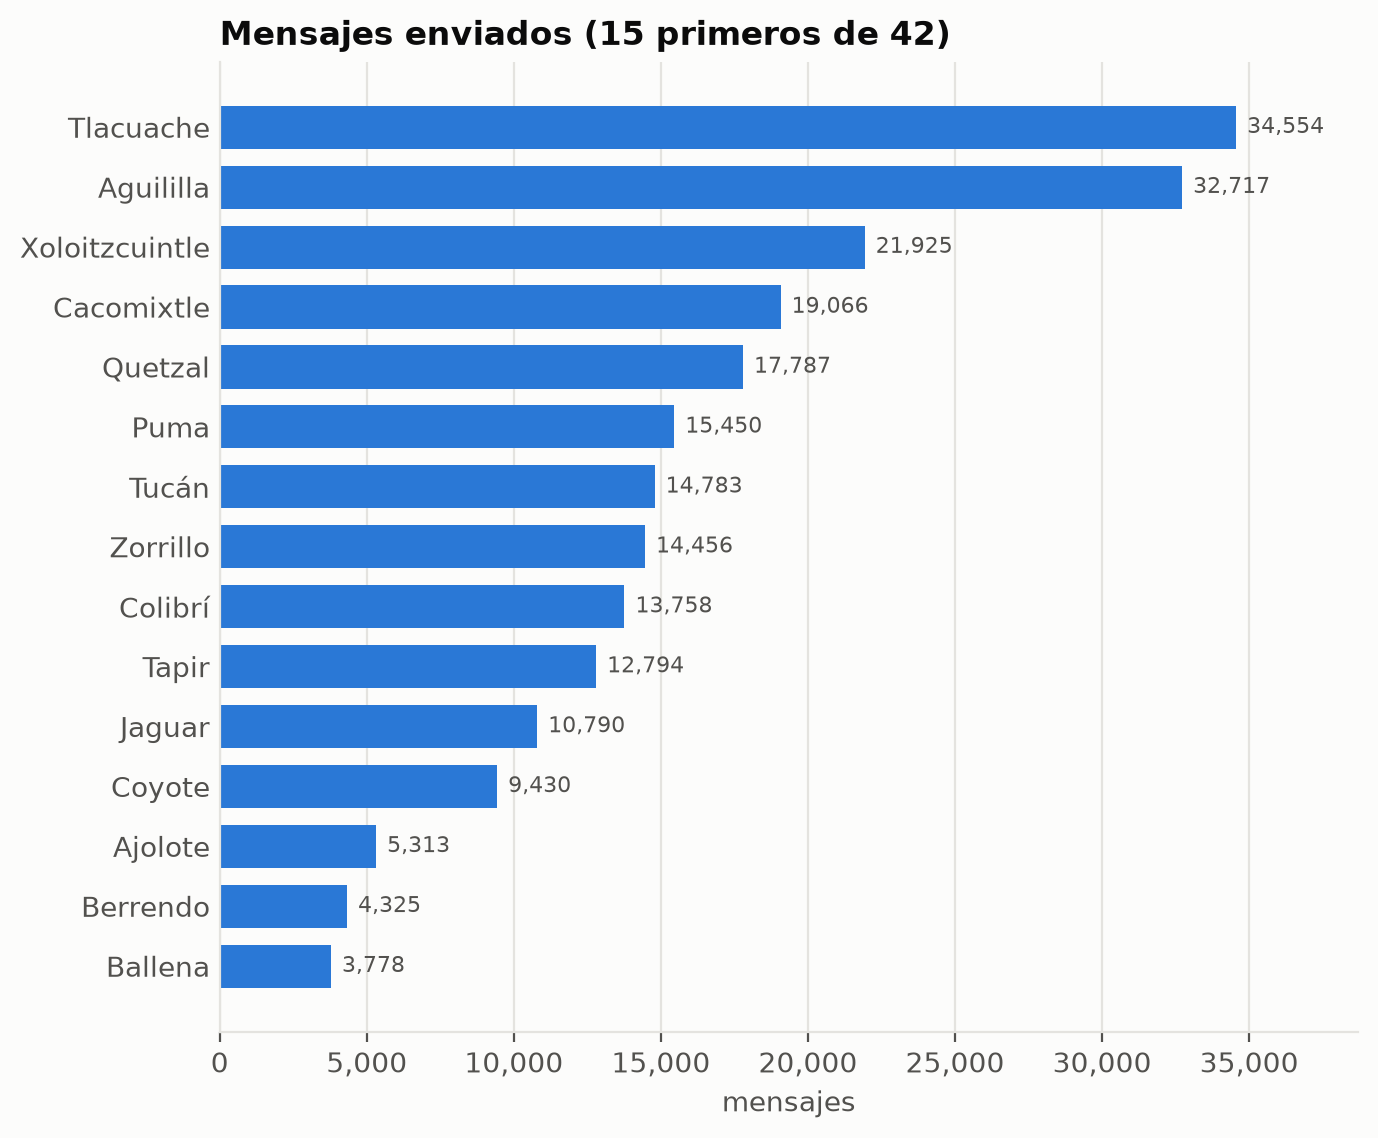

In [ ]:
by_sender = mo.sql(
    f"""
    SELECT
        sender AS usuario,
        count(*) AS mensajes,
        round(100 * count(*) / sum(count(*)) OVER (), 1) AS pct
    FROM messages
    WHERE sender IS NOT NULL
    GROUP BY sender
    ORDER BY mensajes DESC
    """,
    engine=con,
    output=False,
)
barh(
    by_sender["usuario"][:15],
    by_sender["mensajes"][:15],
    "Mensajes enviados (15 primeros de 42)",
    "mensajes",
)

In [ ]:
_top = by_sender.row(0, named=True)
_half = (by_sender["mensajes"].cum_sum() / by_sender["mensajes"].sum() <= 0.5).sum() + 1
note(
    f"**{_top['usuario']}** manda más mensajes que nadie: **{_top['mensajes']:,}** "
    f"({_top['pct']}% de todos los mensajes del grupo), seguido de "
    f"{by_sender['usuario'][1]} con {by_sender['mensajes'][1]:,}. La conversación está "
    f"concentrada: entre **{_half}** de las {len(by_sender)} personas escriben la mitad "
    f"de los mensajes, y la última del grupo mandó {by_sender['mensajes'][-1]:,}."
)

Tlacuache manda más mensajes que nadie: 34,554 (13.3% de todos los mensajes del grupo), seguido de Aguililla con 32,717. La conversación está concentrada: entre 6 de las 42 personas escriben la mitad de los mensajes, y la última del grupo mandó 1.

## 12. ¿Cuántas palabras por mensaje de texto escribe cada quien?

Solo mensajes de texto (`message_type = 'text'`), porque un sticker o una foto sin pie
no tienen palabras y bajarían el promedio de quien manda muchos.

In [ ]:
words_per_sender = mo.sql(
    f"""
    SELECT
        sender AS usuario,
        count(*) AS mensajes_de_texto,
        round(avg(n_words), 2) AS palabras_por_mensaje,
        median(n_words) AS mediana,
        max(n_words) AS mensaje_mas_largo
    FROM messages
    WHERE sender IS NOT NULL AND message_type = 'text'
    GROUP BY sender
    HAVING count(*) >= 100
    ORDER BY palabras_por_mensaje DESC
    """,
    engine=con,
)

usuario,mensajes_de_texto,palabras_por_mensaje,mediana,mensaje_mas_largo
"""Correcaminos""",392,58.72,23.5,950
"""Garza""",354,7.92,6.0,271
"""Cocodrilo""",1845,6.72,5.0,592
"""Vaquita""",187,6.52,6.0,21
"""Jabalí""",208,6.31,4.0,47
"""Zopilote""",1791,5.84,4.0,137
"""Ballena""",3366,5.56,5.0,139
"""Mapache""",3174,5.55,4.0,557
"""Tapir""",10700,5.31,4.0,355
"""Ajolote""",4592,5.19,4.0,97


In [ ]:
_most = words_per_sender.row(0, named=True)
_second = words_per_sender.row(1, named=True)
_least = words_per_sender.row(-1, named=True)
_skewed = (words_per_sender["mediana"] < words_per_sender["palabras_por_mensaje"]).sum()
note(
    f"El promedio va de **{_most['palabras_por_mensaje']}** palabras por mensaje "
    f"({_most['usuario']}) a **{_least['palabras_por_mensaje']}** ({_least['usuario']}), "
    f"una diferencia de {_most['palabras_por_mensaje'] / _least['palabras_por_mensaje']:.0f} "
    f"veces. {_most['usuario']} es un caso aparte: le sigue {_second['usuario']} con "
    f"{_second['palabras_por_mensaje']}, así que el resto del grupo se mueve en un rango "
    "estrecho de mensajes cortos.\n\n"
    f"En **{_skewed} de {len(words_per_sender)}** usuarios la mediana es menor que el "
    "promedio: casi todos escriben mensajes de unas pocas palabras y, de vez en cuando, "
    "uno largo que jala el promedio hacia arriba. Se excluye a quienes escribieron "
    "menos de 100 mensajes de texto, donde el promedio es puro ruido."
)

El promedio va de 58.72 palabras por mensaje (Correcaminos) a 3.07 (Manatí), una diferencia de 19 veces. Correcaminos es un caso aparte: le sigue Garza con 7.92, así que el resto del grupo se mueve en un rango estrecho de mensajes cortos. 
 En 33 de 33 usuarios la mediana es menor que el promedio: casi todos escriben mensajes de unas pocas palabras y, de vez en cuando, uno largo que jala el promedio hacia arriba. Se excluye a quienes escribieron menos de 100 mensajes de texto, donde el promedio es puro ruido.

## 13. ¿Quién manda más palabras, más emojis y más stickers?

In [ ]:
totals = mo.sql(
    f"""
    SELECT
        sender AS usuario,
        sum(n_words) AS palabras,
        sum(n_emojis) AS emojis,
        count(*) FILTER (message_type = 'sticker') AS stickers,
        count(*) AS mensajes
    FROM messages
    WHERE sender IS NOT NULL
    GROUP BY sender
    ORDER BY palabras DESC
    LIMIT 10
    """,
    engine=con,
)

usuario,palabras,emojis,stickers,mensajes
"""Tlacuache""",148286,673,1881,34554
"""Aguililla""",124979,664,5428,32717
"""Xoloitzcuintle""",97488,1110,1869,21925
"""Quetzal""",77826,349,1877,17787
"""Cacomixtle""",71082,587,181,19066
"""Zorrillo""",67519,300,204,14456
"""Colibrí""",65255,2375,219,13758
"""Puma""",64542,484,1654,15450
"""Tapir""",58218,439,1247,12794
"""Jaguar""",44219,293,1336,10790


In [ ]:
champions = mo.sql(
    f"""
    WITH por_usuario AS (
        SELECT
            sender,
            sum(n_words) AS palabras,
            sum(n_emojis) AS emojis,
            count(*) FILTER (message_type = 'sticker') AS stickers
        FROM messages
        WHERE sender IS NOT NULL
        GROUP BY sender
    )
    (SELECT 'palabras' AS categoria, sender AS usuario, palabras AS total
     FROM por_usuario ORDER BY palabras DESC LIMIT 1)
    UNION ALL
    (SELECT 'emojis', sender, emojis FROM por_usuario ORDER BY emojis DESC LIMIT 1)
    UNION ALL
    (SELECT 'stickers', sender, stickers FROM por_usuario ORDER BY stickers DESC LIMIT 1)
    """,
    engine=con,
    output=False,
)
note(
    "Cada categoría tiene su campeón: "
    + "; ".join(
        f"**{row['categoria']}**: {row['usuario']} ({row['total']:,})"
        for row in champions.iter_rows(named=True)
    )
    + ". Quien manda más mensajes no es necesariamente quien manda más palabras, "
    "porque hay quien conversa con muchos mensajes cortos y quien escribe párrafos. "
    "Los emojis y los stickers son gustos personales: el grupo manda el doble de "
    "stickers que de emojis, y unos pocos concentran la mayoría."
)

Cada categoría tiene su campeón: palabras : Tlacuache (148,286); emojis : Colibrí (2,375); stickers : Aguililla (5,428). Quien manda más mensajes no es necesariamente quien manda más palabras, porque hay quien conversa con muchos mensajes cortos y quien escribe párrafos. Los emojis y los stickers son gustos personales: el grupo manda el doble de stickers que de emojis, y unos pocos concentran la mayoría.

## 14. ¿Cuándo se escribe? Día de la semana y hora

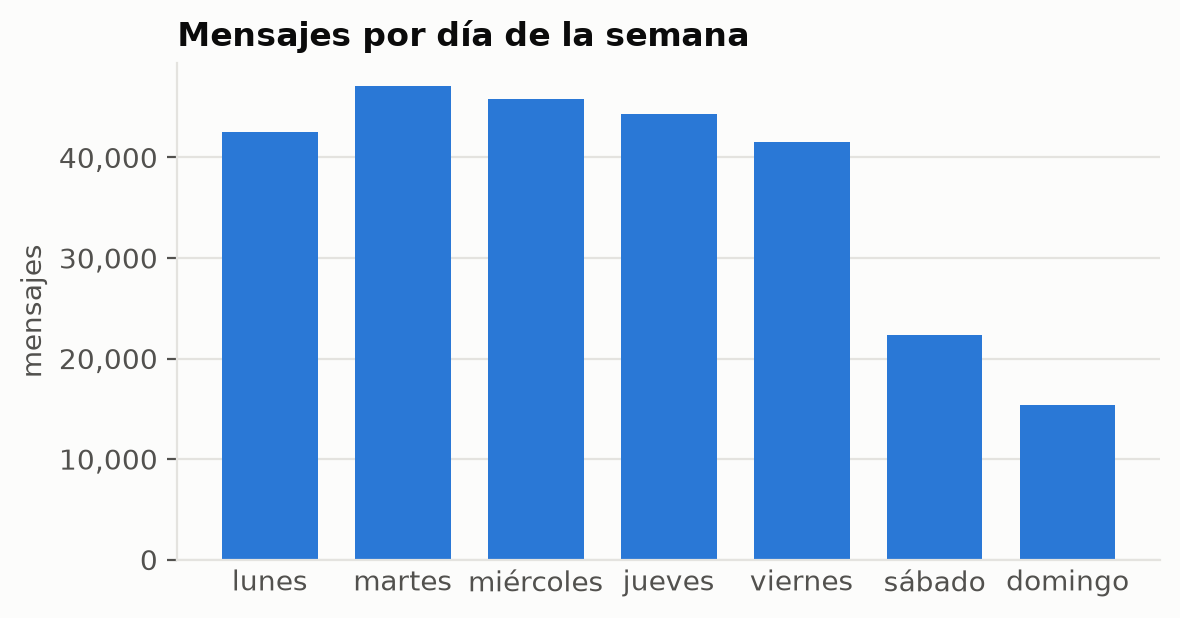

In [ ]:
by_weekday = mo.sql(
    f"""
    SELECT
        ['lunes', 'martes', 'miércoles', 'jueves', 'viernes', 'sábado', 'domingo'][isodow(timestamp)] AS dia,
        isodow(timestamp) AS orden,
        count(*) AS mensajes,
        round(count(*) / count(DISTINCT timestamp::DATE), 0) AS por_dia
    FROM messages
    GROUP BY ALL
    ORDER BY orden
    """,
    engine=con,
    output=False,
)
columns(by_weekday["dia"], by_weekday["mensajes"], "Mensajes por día de la semana", "mensajes")

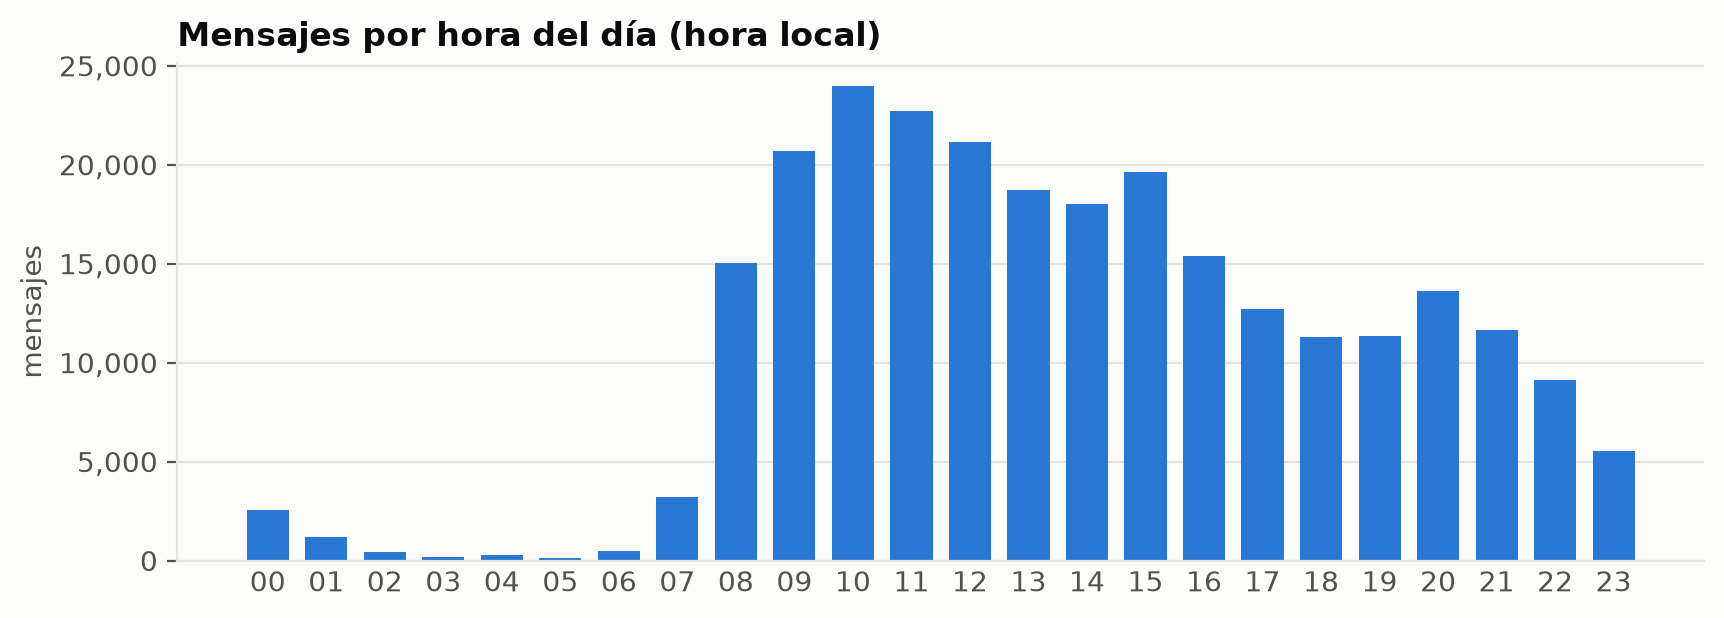

In [ ]:
by_hour = mo.sql(
    f"""
    SELECT hour(timestamp) AS hora, count(*) AS mensajes
    FROM messages
    GROUP BY hora
    ORDER BY hora
    """,
    engine=con,
    output=False,
)
columns(
    [f"{hour:02d}" for hour in by_hour["hora"]],
    by_hour["mensajes"],
    "Mensajes por hora del día (hora local)",
    "mensajes",
)

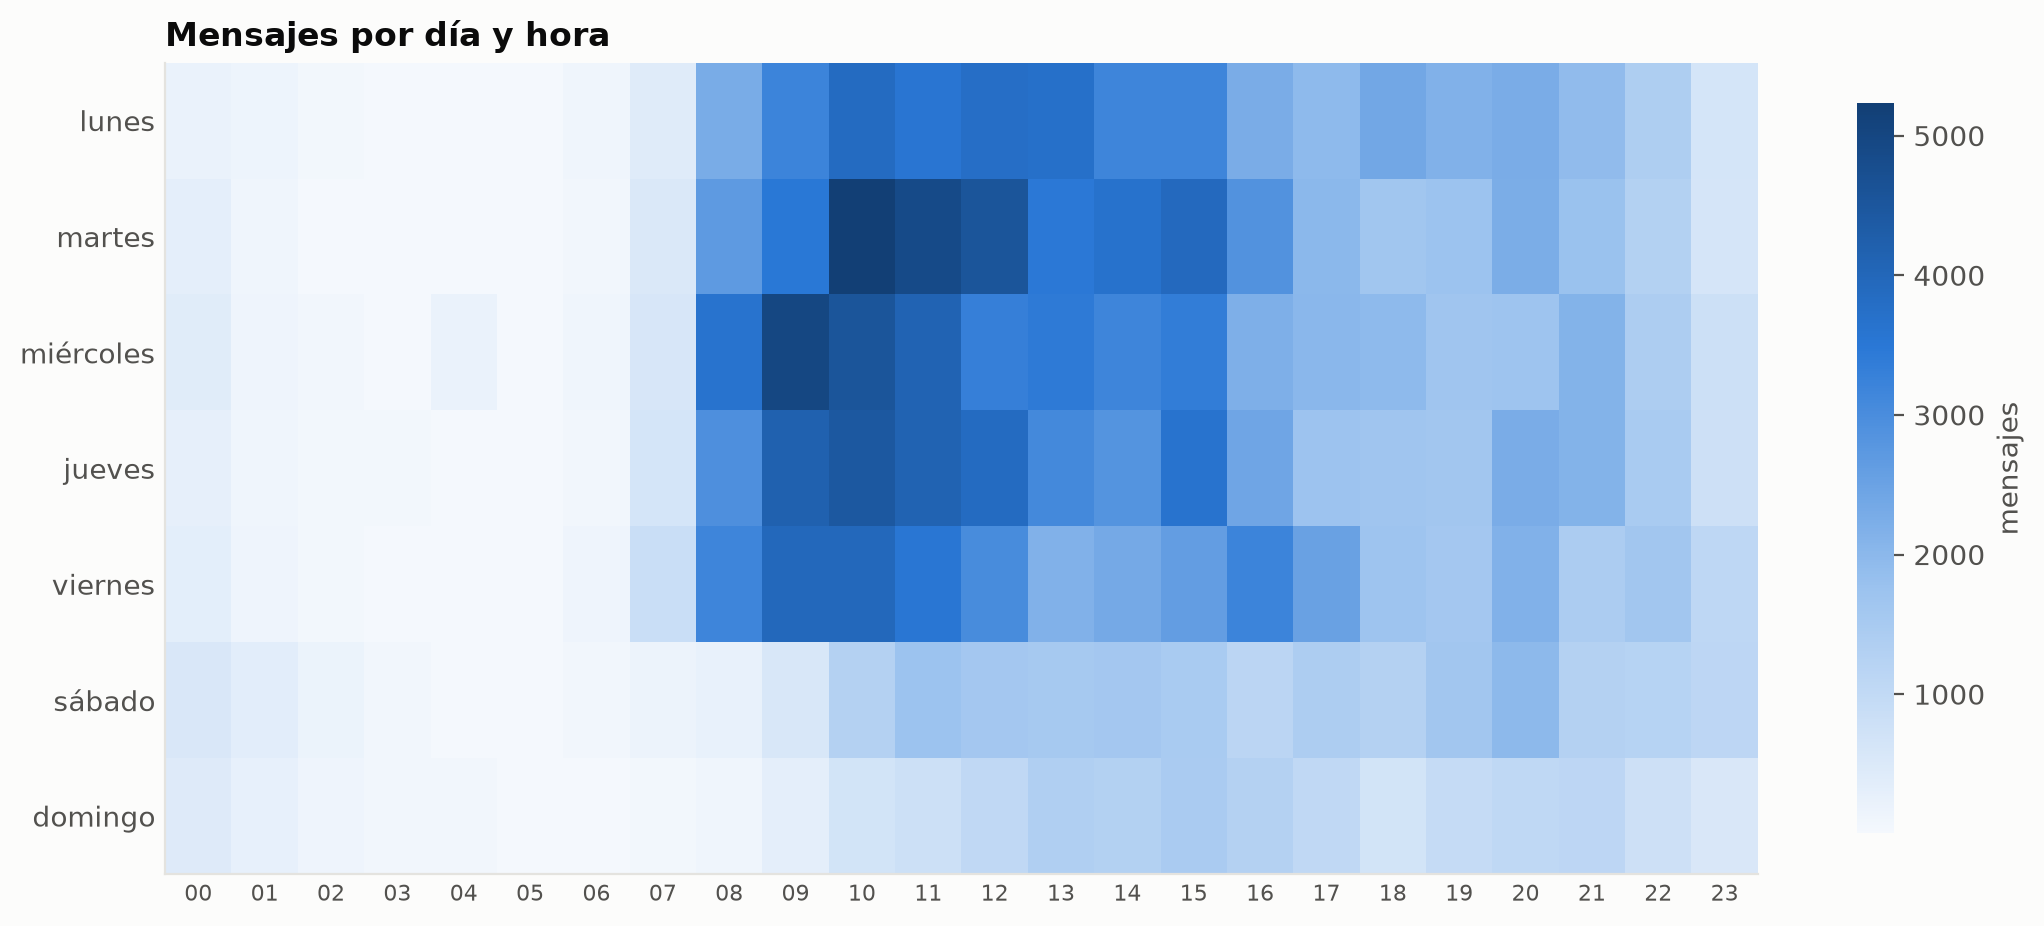

In [ ]:
weekday_hour = mo.sql(
    f"""
    SELECT isodow(timestamp) AS dia, hour(timestamp) AS hora, count(*) AS mensajes
    FROM messages
    GROUP BY ALL
    ORDER BY dia, hora
    """,
    engine=con,
    output=False,
)
_counts = {(row["dia"], row["hora"]): row["mensajes"] for row in weekday_hour.iter_rows(named=True)}
_days = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]
heatmap(
    [[_counts.get((day, hour), 0) for hour in range(24)] for day in range(1, 8)],
    _days,
    [f"{hour:02d}" for hour in range(24)],
    "Mensajes por día y hora",
    "mensajes",
)

In [ ]:
_busiest = by_weekday.sort("mensajes", descending=True).row(0, named=True)
_quietest = by_weekday.sort("mensajes").row(0, named=True)
_peak = by_hour.sort("mensajes", descending=True).row(0, named=True)
_night = by_hour.filter(by_hour["hora"].is_between(4, 7))["mensajes"].sum()
note(
    f"**Sí hay patrón semanal**: el día más activo es el **{_busiest['dia']}** "
    f"({_busiest['mensajes']:,} mensajes) y el más callado el **{_quietest['dia']}** "
    f"({_quietest['mensajes']:,}), "
    f"{_busiest['mensajes'] / _quietest['mensajes']:.1f} veces menos. Los cinco días "
    "entre semana se parecen entre sí y el fin de semana cae claramente: es un grupo "
    "que acompaña la rutina de clases, y en sábado y domingo la gente se ve en persona "
    "o se desconecta.\n\n"
    f"**Por hora el patrón es más marcado**: el pico es a las **{_peak['hora']}:00** "
    f"({_peak['mensajes']:,} mensajes), dentro del bloque de media mañana y mediodía, y "
    f"de las 4 a las 7 de la mañana el grupo casi duerme ({_night:,} mensajes en total "
    "entre las cuatro horas). El mapa de calor muestra que ese ritmo diario se repite "
    "igual de lunes a viernes, y que las madrugadas con actividad caen sobre todo en "
    "fin de semana."
)

Sí hay patrón semanal : el día más activo es el martes (47,078 mensajes) y el más callado el domingo (15,333), 3.1 veces menos. Los cinco días entre semana se parecen entre sí y el fin de semana cae claramente: es un grupo que acompaña la rutina de clases, y en sábado y domingo la gente se ve en persona o se desconecta. 
 Por hora el patrón es más marcado : el pico es a las 10:00 (23,958 mensajes), dentro del bloque de media mañana y mediodía, y de las 4 a las 7 de la mañana el grupo casi duerme (4,090 mensajes en total entre las cuatro horas). El mapa de calor muestra que ese ritmo diario se repite igual de lunes a viernes, y que las madrugadas con actividad caen sobre todo en fin de semana.

## 15. ¿Qué palabras se usan más?

Primero todas las palabras, incluidas las vacías, para ver por qué hay que filtrarlas;
después solo las que tienen contenido.

In [ ]:
all_words = mo.sql(
    f"""
    SELECT token AS palabra, count(*) AS veces
    FROM tokens
    WHERE is_alpha
    GROUP BY token
    ORDER BY veces DESC
    LIMIT 10
    """,
    engine=con,
)

palabra,veces
"""de""",33263
"""que""",31850
"""el""",30562
"""a""",26822
"""no""",26302
"""la""",26220
"""y""",20635
"""en""",18718
"""es""",15403
"""me""",12750


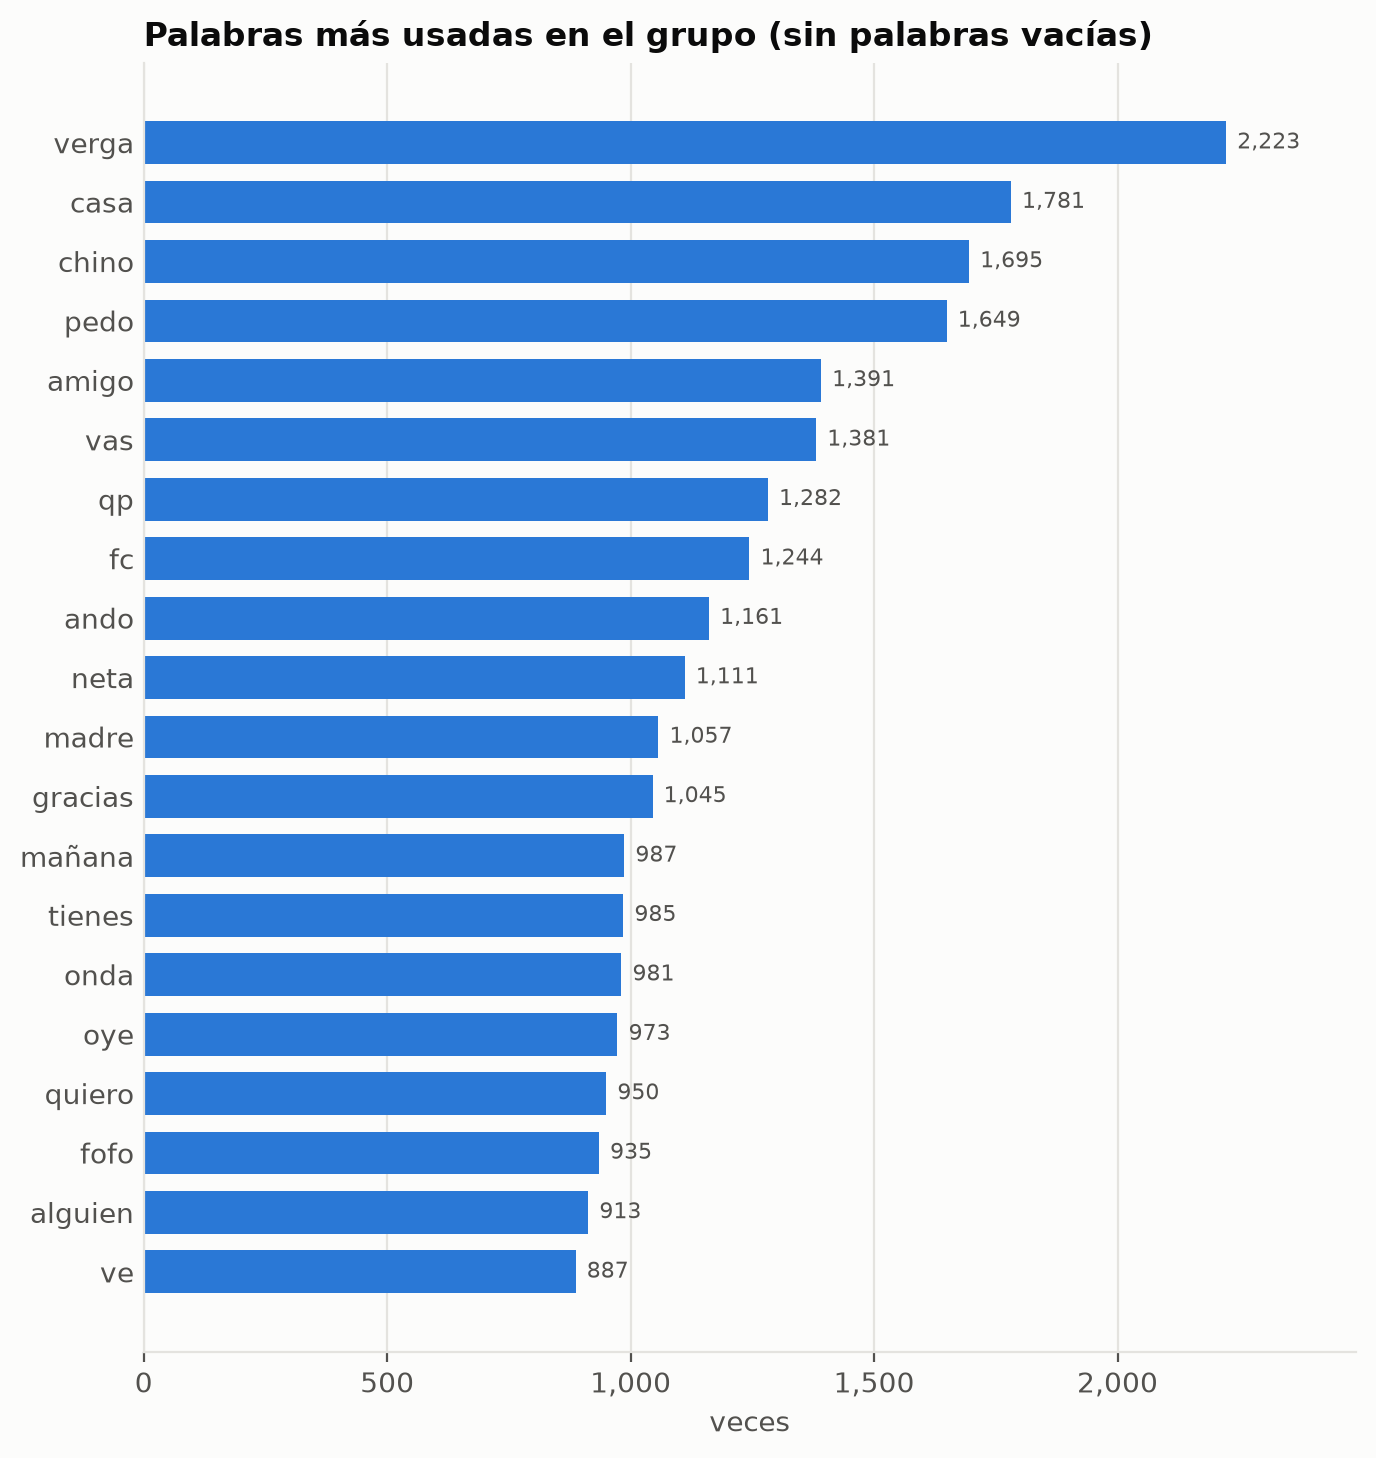

In [ ]:
top_content_words = mo.sql(
    f"""
    SELECT token AS palabra, count(*) AS veces
    FROM tokens
    WHERE is_alpha AND NOT is_stop
    GROUP BY token
    ORDER BY veces DESC
    LIMIT 20
    """,
    engine=con,
    output=False,
)
barh(
    top_content_words["palabra"],
    top_content_words["veces"],
    "Palabras más usadas en el grupo (sin palabras vacías)",
    "veces",
)

In [ ]:
words_by_sender = mo.sql(
    f"""
    WITH por_usuario AS (
        SELECT m.sender, t.token, count(*) AS veces
        FROM tokens AS t
        JOIN messages AS m USING (message_id)
        WHERE t.is_alpha AND NOT t.is_stop AND m.sender IS NOT NULL
        GROUP BY ALL
    ),
    ordenadas AS (
        SELECT *, row_number() OVER (PARTITION BY sender ORDER BY veces DESC, token) AS lugar
        FROM por_usuario
    )
    SELECT
        sender AS usuario,
        string_agg(token || ' (' || veces || ')', ', ' ORDER BY lugar) AS palabras_mas_usadas
    FROM ordenadas
    WHERE lugar <= 5
    GROUP BY sender
    ORDER BY usuario
    """,
    engine=con,
)

usuario,palabras_mas_usadas
"""Aguililla""","""tung (325), verga (316), casa (259), vas (201), qp (197)"""
"""Ajolote""","""bn (78), ola (77), hola (55), casa (43), fc (43)"""
"""Armadillo""","""fc (52), feliz (29), gente (25), hola (25), ando (23)"""
"""Ballena""","""alv (54), ln (38), verga (38), loco (37), agua (36)"""
"""Berrendo""","""casa (48), qp (43), ando (38), gracias (37), fc (36)"""
"""Cacomixtle""","""pedo (244), verga (193), casa (188), alv (186), amigo (167)"""
"""Chachalaca""","""sii (31), casa (28), fc (25), grupo (23), ño (23)"""
"""Cocodrilo""","""años (23), casa (20), chilo (19), alguien (18), arco (17)"""
"""Colibrí""","""gay (253), lowkey (164), ln (127), neta (125), lit (112)"""
"""Correcaminos""","""quieres (127), ayudarte (93), datos (55), estás (55), you (47)"""


In [ ]:
note(
    "Sin filtrar, las diez palabras más usadas son todas vacías (*de*, *que*, *el*, "
    "*no*...): son las que sostienen cualquier texto en español y no dicen nada del "
    "grupo. Filtrando las vacías (las de spaCy más las muletillas del chat, sección 8) "
    "aparece de qué se habla: las cinco primeras son "
    + ", ".join(
        f"**{row['palabra']}** ({row['veces']:,})"
        for row in top_content_words.head(5).iter_rows(named=True)
    )
    + ". Son sobre todo groserías que en el habla del norte de México funcionan como "
    "muletilla, y palabras de quedar de verse (*casa*, *mañana*, *alguien*): el grupo "
    "se usa para organizar planes más que para conversar de un tema.\n\n"
    "Por usuario, las listas se parecen entre sí en las primeras palabras y se "
    "distinguen después: cada quien tiene sus propias muletillas, y ahí se nota quién "
    "organiza planes, quién habla de futbol y quién de la escuela."
)

Sin filtrar, las diez palabras más usadas son todas vacías ( de , que , el , no ...): son las que sostienen cualquier texto en español y no dicen nada del grupo. Filtrando las vacías (las de spaCy más las muletillas del chat, sección 8) aparece de qué se habla: las cinco primeras son verga (2,223), casa (1,781), chino (1,695), pedo (1,649), amigo (1,391). Son sobre todo groserías que en el habla del norte de México funcionan como muletilla, y palabras de quedar de verse ( casa , mañana , alguien ): el grupo se usa para organizar planes más que para conversar de un tema. 
 Por usuario, las listas se parecen entre sí en las primeras palabras y se distinguen después: cada quien tiene sus propias muletillas, y ahí se nota quién organiza planes, quién habla de futbol y quién de la escuela.

## 16. ¿Cuáles son los adjetivos más usados?

Por lema, para juntar *buena*, *buenas* y *bueno*. Aquí no se filtran las palabras
vacías: la lista de spaCy incluye justo los adjetivos más comunes (sección 9).

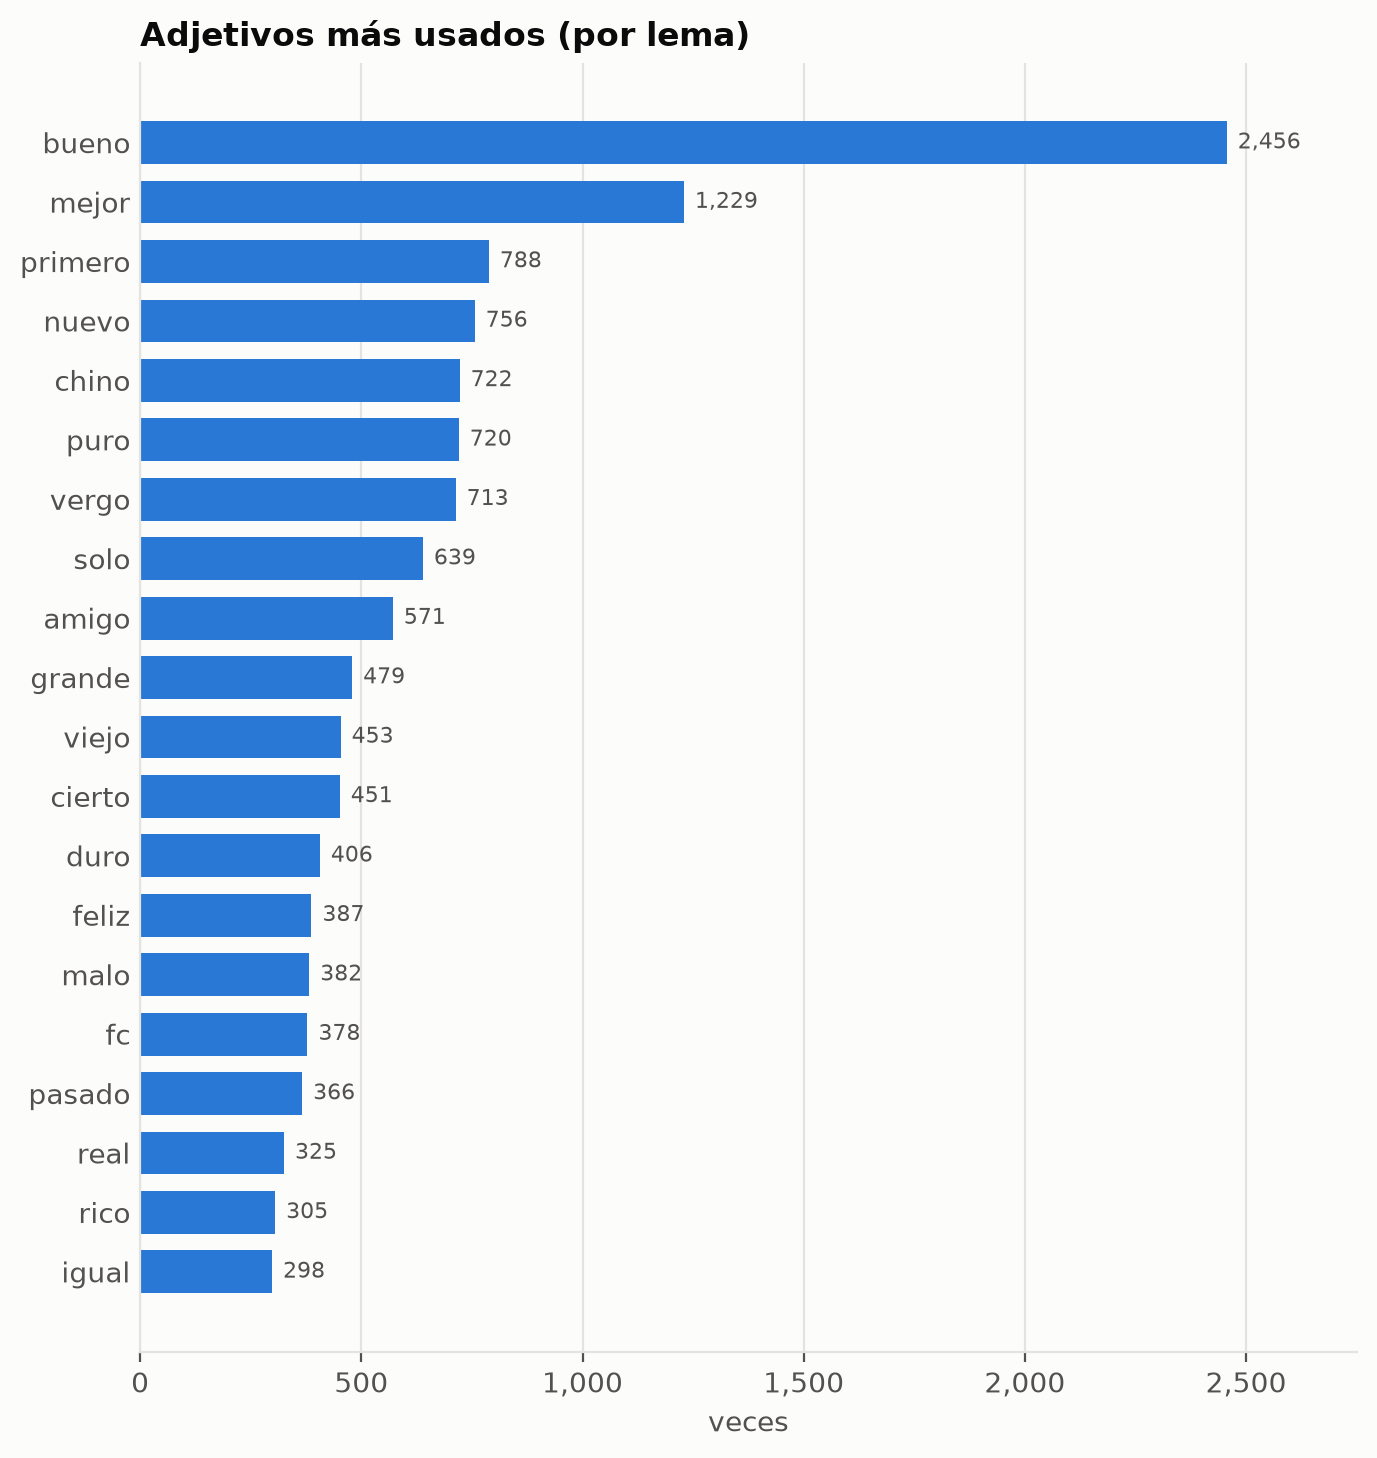

In [ ]:
top_adjectives = mo.sql(
    f"""
    SELECT lemma AS adjetivo, count(*) AS veces
    FROM tokens
    WHERE pos = 'ADJ' AND is_alpha AND NOT is_laugh AND length(token) > 1
    GROUP BY lemma
    ORDER BY veces DESC
    LIMIT 20
    """,
    engine=con,
    output=False,
)
barh(top_adjectives["adjetivo"], top_adjectives["veces"], "Adjetivos más usados (por lema)", "veces")

In [ ]:
note(
    f"El adjetivo más usado es **{top_adjectives['adjetivo'][0]}** "
    f"({top_adjectives['veces'][0]:,} veces), seguido de {top_adjectives['adjetivo'][1]} y "
    f"{top_adjectives['adjetivo'][2]}. Son adjetivos de valoración —bueno, mejor, nuevo— "
    "más los que este grupo usa para calificarlo todo, incluidas varias groserías que "
    "en el español de México funcionan como adjetivos.\n\n"
    "Hay que leer la lista con reserva: `es_core_news_sm` se entrenó con noticias, y "
    "en un chat sin puntuación confunde sustantivos y verbos con adjetivos (sección "
    "9). Los primeros lugares son sólidos; hacia el final de la lista aparecen "
    "palabras mal etiquetadas."
)

El adjetivo más usado es bueno (2,456 veces), seguido de mejor y primero. Son adjetivos de valoración —bueno, mejor, nuevo— más los que este grupo usa para calificarlo todo, incluidas varias groserías que en el español de México funcionan como adjetivos. 
 Hay que leer la lista con reserva: es_core_news_sm se entrenó con noticias, y en un chat sin puntuación confunde sustantivos y verbos con adjetivos (sección 9). Los primeros lugares son sólidos; hacia el final de la lista aparecen palabras mal etiquetadas.

## Resumen

- La conversación está concentrada en unas pocas personas, y quien más mensajes manda
  no es siempre quien más palabras escribe: hay estilos de muchos mensajes cortos y
  estilos de párrafos.
- El grupo se expresa más con stickers que con emojis.
- Hay un ritmo diario muy marcado (pico a media mañana y mediodía, silencio de
  madrugada) y un patrón semanal claro: de lunes a viernes se escribe casi el doble
  que en fin de semana.
- Las palabras más usadas, una vez quitadas las vacías, son groserías usadas como
  muletilla y palabras para quedar de verse; el contenido del grupo aparece al leer
  más allá de las primeras posiciones y al comparar las listas por usuario.
- Los adjetivos más usados son de valoración, con las limitaciones de un modelo
  entrenado con noticias.